<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
import numpy as np

In [4]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [5]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

C:\Users\kevin\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\kevin\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\kevin\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [6]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [7]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


l'exploration de chaque fichier (dimensions, types, doublons, valeurs manquantes) est faite manuellement et répétée pour chaque colonne/dataset. Besoin : accélérer cette étape via un outil de profiling automatique.

In [8]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_erp, title="Rapport EDA - erp.xlsx")
profile.to_notebook_iframe()

C:\Users\kevin\AppData\Local\Temp\ipykernel_20432\3054670782.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 375.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
import sweetviz as sv
report = sv.analyze(df_erp)
report.show_html('sweetviz_erp.html')

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_erp.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [10]:
#Afficher les 5 premières lignes de la table
display(df_erp.head())

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [11]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp['product_id'].duplicated().any()

np.False_

In [12]:
#Afficher les valeurs distinctes de la colonne stock_status
display(df_erp['stock_status'].unique())
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
display(df_erp['stock_status'].value_counts())
display((df_erp['stock_quantity']<=0).sum())
display((df_erp['stock_quantity']>0).sum())

array(['instock', 'outofstock'], dtype=object)

stock_status
instock       733
outofstock     92
Name: count, dtype: int64

np.int64(92)

np.int64(733)

In [13]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] == 0, 'outofstock', 'instock')
display(df_erp.head())

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [14]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [15]:
# Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
# True vaut 1 et False 0
# Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp['stock_status'] == df_erp['stock_status_2']).sum()

np.int64(821)

In [16]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
display(df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [17]:
#Corriger la ou les données incohérentes
df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock')
df_erp['stock_status'] = np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock')
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
(df_erp['stock_status'] == df_erp['stock_status_2']).sum()

np.int64(825)

In [18]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
del df_erp['stock_status_2']
display(df_erp.head())

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [19]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
display(df_erp['price'].isnull().sum())
#Afficher le prix minimum de la colonne "price"
display(df_erp['price'].min())
#Afficher le prix maximum de la colonne "price"
display(df_erp['price'].max())
#Afficher les prix inférieurs ou égal à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp[df_erp['price'] < 0])

np.int64(0)

-20.0

225.0

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
469,5017,0,-8.0,0,outofstock,4.34
739,6594,0,-9.1,19,instock,4.61


In [20]:
#Afficher les produits dont price <= à purchase_price
display(df_erp[df_erp['price'] <= df_erp['purchase_price']])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.00,0,outofstock,10.33
210,4355,1,12.65,97,instock,77.48
391,4864,0,8.30,0,outofstock,9.99
469,5017,0,-8.00,0,outofstock,4.34
724,6324,0,92.00,18,instock,99.00
739,6594,0,-9.10,19,instock,4.61
817,7196,0,31.00,55,instock,31.20


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [21]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
display(df_erp['stock_quantity'].min())
#Afficher la quantité maximum de la colonne "stock_quantity"
display(df_erp['stock_quantity'].max())
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp[df_erp['stock_quantity'] < 0])

-10

145

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [22]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].unique()

array([1, 0])

In [23]:
#Quelles sont les colonnes à conserver selon vous?
#Techniquement il faudrait faire un filtre sur onsale_web et garder les produits vendus sur le web
#mais on va tout garder, on sait jamais s'il y a eu des erreurs de manipulations en interne sur le logiciel

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [24]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
display(df_erp['purchase_price'].isnull().sum())
#Afficher le prix minimum de la colonne "purchase_price"
display(df_erp['purchase_price'].min())
#Afficher le prix maximum de la colonne "purchase_price"
display(df_erp['purchase_price'].max())

np.int64(0)

2.74

137.81

In [25]:
#afficher les produits dont le prix d'achat est supérieur ou égal au prix
display(df_erp[df_erp['purchase_price'] >= df_erp['price']])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.00,0,outofstock,10.33
210,4355,1,12.65,97,instock,77.48
391,4864,0,8.30,0,outofstock,9.99
469,5017,0,-8.00,0,outofstock,4.34
724,6324,0,92.00,18,instock,99.00
739,6594,0,-9.10,19,instock,4.61
817,7196,0,31.00,55,instock,31.20


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [26]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s)".format(df_web.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 1513 observation(s)
Le tableau comporte 29 colonne(s)


In [27]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [28]:
# perso : savoir s'il y a des doublons
display(df_web.duplicated().any())

np.True_

In [29]:
# perso : suppression des doublons
df_web_clean = df_web[df_web['post_type'] == 'product']

In [30]:
# perso : savoir s'il y a des doublons
display(df_web_clean.duplicated().any())
display(df_web_clean.info())

np.False_

<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 2 to 1509
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    714 non-null    object        
 1   virtual                716 non-null    int64         
 2   downloadable           716 non-null    int64         
 3   rating_count           716 non-null    int64         
 4   average_rating         716 non-null    float64       
 5   total_sales            716 non-null    float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            716 non-null    float64       
 9   post_date              716 non-null    datetime64[ns]
 10  post_date_gmt          716 non-null    datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           715 non-null    object        
 13  post_titl

None

In [31]:
# afficher les lignes sku est NaN
display(df_web_clean[df_web_clean['sku'].isnull()])

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NaN,0,0,0,0.0,-17.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [32]:
# afficher produit dont post name est pierre-jean-villa-condrieu-suspendu-2018
display(df_web_clean[df_web_clean['post_name'] == 'pierre-jean-villa-condrieu-suspendu-2018'])

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [33]:
# afficher produit dont post name est pierre-jean-villa-cote-rotie-fongeant-2017
display(df_web_clean[df_web_clean['post_name'] == 'pierre-jean-villa-cote-rotie-fongeant-2017'])

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1087,NaN,0,0,0,0.0,-17.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [34]:
# perso : suppresion des lignes où sku est NaN
df_web_clean = df_web_clean.dropna(subset=['sku'])
display(df_web_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    714 non-null    object        
 1   virtual                714 non-null    int64         
 2   downloadable           714 non-null    int64         
 3   rating_count           714 non-null    int64         
 4   average_rating         714 non-null    float64       
 5   total_sales            714 non-null    float64       
 6   tax_status             714 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            714 non-null    float64       
 9   post_date              714 non-null    datetime64[ns]
 10  post_date_gmt          714 non-null    datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           713 non-null    object        
 13  post_titl

None

In [35]:
# creation sku_2, si sku est vide alors post_title sinon sku
# df_web_clean['sku_2'] = np.where(df_web_clean['sku'].isnull(), df_web_clean['post_title'], df_web_clean['sku'])


In [36]:
# affichage sku est vide
# display(df_web_clean[df_web_clean['sku'].isnull()])

In [37]:
# remplacemenet sku par sku_2 et suppression sku_2
# df_web_clean['sku'] = df_web_clean['sku_2']
# del df_web_clean['sku_2']

In [38]:
#Selon vous, quelles sont les colonnes à conserver ?
print("sku, total_sales, product_type, post_title")

sku, total_sales, product_type, post_title


In [39]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
colonnes_a_garder = ['sku', 'total_sales', 'product_type','post_title']
df_web_clean = df_web_clean[colonnes_a_garder]
display(df_web_clean.head())

,sku,total_sales,product_type,post_title
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017
6,16515,10.0,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018
11,16585,15.0,Vin,Xavier Frissant Touraine Sauvignon 2019
14,12869,7.0,Vin,Stéphane Tissot Arbois D.D. 2016


In [40]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
display(df_web_clean['sku'].unique())

array([14692, 15328, 16515, 16585, 12869, 15575, 14338, 16560, 15361,
       15022, 16342, 16029, 13754, 14680, 9636, 13849, 15481, 15448,
       15441, 804, 16071, 12882, 16053, 13766, 12640, 15476, 16038, 14864,
       16044, 15324, 15413, 13809, 15895, 15849, 12315, 15934, 15148,
       15781, 15106, 15490, 14507, 16307, 13736, 16037, 12587, 16305,
       16131, 13435, 15758, 14509, 14768, 16505, 15871, 11602, 13127,
       13520, 13032, 15436, 15910, 16263, 15138, 16580, 13905, 13557,
       14975, 15341, 15415, 16065, 15479, 16151, 15127, 15140, 15779,
       9937, 15281, 15315, 15668, 15161, 15792, 15921, 15870, 15690,
       15561, 15539, 16320, 3509, 2534, 11586, 14819, 15705, 15254, 15554,
       14451, 16274, 14696, 14573, 16238, 15834, 15141, 15038, 15238,
       16586, 15664, 14527, 15707, 15269, 14845, 14700, 15440, 15759,
       11277, 15676, 15731, 16525, 15785, 14699, 15718, 14372, 15881,
       15426, 16023, 14661, 15675, 15351, 12791, 13958, '13127-1', 11849,
       1

In [41]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
display(df_web_clean[df_web_clean['sku'] == "bon-cadeau-25-euros"])

,sku,total_sales,product_type,post_title
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€


In [42]:
#afficher les produits dont le total_sales est inférieur à 0
display(df_web_clean[df_web_clean['total_sales'] < 0])

,sku,total_sales,product_type,post_title


In [43]:
#afficher les produits dont le product_type est vide
display(df_web_clean[df_web_clean['product_type'].isnull()])

,sku,total_sales,product_type,post_title
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€


In [44]:
#afficher les produits dont le post_title est vide
display(df_web_clean[df_web_clean['post_title'].isnull()])

,sku,total_sales,product_type,post_title


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [45]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations : ",df_liaison.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristiques : ",df_liaison.shape[1])

Nombre d'observations :  825
Nombre de caractéristiques :  2


In [46]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [47]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison['product_id'].duplicated().any()

np.False_

In [48]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison['id_web'].duplicated().any()

np.True_

In [49]:
#Avons-nous des articles sans correspondance?
display(df_liaison[df_liaison['id_web'].isnull()])

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [50]:
df_liaison[df_liaison['id_web'].duplicated(keep=False)]


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [51]:
# perso : suppression des lignes id_web est null
df_liaison_clean = df_liaison.dropna(subset=['id_web'])


In [52]:
df_liaison_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  734 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 17.2+ KB


In [53]:
df_liaison_clean['id_web'].duplicated().any()

np.False_

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [54]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison_clean, on='product_id', how='left')
display(df_merge.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
 6   id_web          734 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 45.2+ KB


None

In [55]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
display(df_merge[df_merge['id_web'].isnull()])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
19,4055,0,86.1,0,outofstock,37.88,NaN
49,4090,0,73.0,0,outofstock,33.79,NaN
50,4092,0,47.0,0,outofstock,25.25,NaN
119,4195,0,14.1,0,outofstock,7.36,NaN
131,4209,0,73.5,0,outofstock,33.01,NaN
...,...,...,...,...,...,...,...
817,7196,0,31.0,55,instock,31.20,NaN
818,7200,0,31.0,6,instock,15.54,NaN
819,7201,0,31.0,18,instock,16.02,NaN
820,7203,0,45.0,30,instock,23.48,NaN


In [56]:
#creation d'une colonne onsale_web 2 : si id_web est pas null alors 1 sinon 0
df_merge['onsale_web_2'] = np.where(df_merge['id_web'].isnull(), 0, 1)

In [57]:
#creation d'une colonne onsale_web 3 : si onsale_web est 1 alors 1 sinon 0
df_merge['onsale_web_3'] = np.where(df_merge['onsale_web'] == 1, 1, 0)

In [58]:
#affichage onsale_web_2 pas égal à onsale_web_3
display(df_merge[df_merge['onsale_web_2'] != df_merge['onsale_web_3']])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,onsale_web_2,onsale_web_3
123,4200,0,5.8,33,instock,3.12,16295,1,0
193,4289,0,22.8,0,outofstock,11.90,13771,1,0
236,4568,0,21.5,0,outofstock,11.22,15065,1,0
241,4584,0,32.3,0,outofstock,17.36,14785,1,0
242,4594,1,144.0,0,outofstock,87.36,NaN,0,1
355,4741,0,12.4,0,outofstock,6.66,12601,1,0
391,4864,0,8.3,0,outofstock,9.99,15154,1,0
394,4869,0,17.2,0,outofstock,9.33,14360,1,0
424,4921,0,13.8,0,outofstock,7.13,15608,1,0
425,4922,0,21.5,0,outofstock,10.55,15586,1,0


In [59]:
#mise a jour de onsale_web (si un des deux colonnes est 1 alors 1 sinon 0)/ supression des colonnes redondantes
df_merge['onsale_web'] = np.where((df_merge['onsale_web_2'] == 1) | (df_merge['onsale_web_3'] == 1), 1, 0)

del df_merge['onsale_web_3']
del df_merge['onsale_web_2']

In [60]:
#creation df_merge_clean et filtre sur id_web non vide
df_merge_clean = df_merge[df_merge['id_web'].notnull()]


In [61]:
df_merge_clean.info()
display(df_merge_clean.head())

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      734 non-null    int64  
 1   onsale_web      734 non-null    int64  
 2   price           734 non-null    float64
 3   stock_quantity  734 non-null    int64  
 4   stock_status    734 non-null    object 
 5   purchase_price  734 non-null    float64
 6   id_web          734 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 45.9+ KB


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815


In [62]:
# suppression des NaN
#df_merge_clean = df_merge.dropna(subset=['id_web'])
#display(df_merge_clean.info())

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [63]:

#Fusionner les datasets df_merge et df_web
df_merge_web = pd.merge(df_merge_clean, df_web_clean, left_on='id_web', right_on='sku', how='left')
df_merge_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      734 non-null    int64  
 1   onsale_web      734 non-null    int64  
 2   price           734 non-null    float64
 3   stock_quantity  734 non-null    int64  
 4   stock_status    734 non-null    object 
 5   purchase_price  734 non-null    float64
 6   id_web          734 non-null    object 
 7   sku             714 non-null    object 
 8   total_sales     714 non-null    float64
 9   product_type    713 non-null    object 
 10  post_title      714 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 63.2+ KB


In [64]:
#Avons-nous des lignes sans correspondance?
display(df_merge_web[df_merge_web['sku'].isnull()])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title
185,4289,1,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaN
227,4568,1,21.5,0,outofstock,11.22,15065,NaN,NaN,NaN,NaN
230,4584,1,32.3,0,outofstock,17.36,14785,NaN,NaN,NaN,NaN
334,4741,1,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaN
368,4864,1,8.3,0,outofstock,9.99,15154,NaN,NaN,NaN,NaN
371,4869,1,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaN
399,4921,1,13.8,0,outofstock,7.13,15608,NaN,NaN,NaN,NaN
400,4922,1,21.5,0,outofstock,10.55,15586,NaN,NaN,NaN,NaN
443,5018,1,15.4,0,outofstock,7.72,15272,NaN,NaN,NaN,NaN
445,5021,1,17.1,0,outofstock,8.92,15630,NaN,NaN,NaN,NaN


In [65]:
#des articles non créé ?

In [66]:
#creation d'une colonne onsale_web 2 : si sku est null alors 0 sinon 1
df_merge_web['onsale_web_2'] = np.where(df_merge_web['sku'].isnull(), 0, 1)

In [67]:
#affichage onsale_web différent de onsale_web_2
display(df_merge_web[df_merge_web['onsale_web'] != df_merge_web['onsale_web_2']])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,onsale_web_2
185,4289,1,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,0
227,4568,1,21.5,0,outofstock,11.22,15065,NaN,NaN,NaN,NaN,0
230,4584,1,32.3,0,outofstock,17.36,14785,NaN,NaN,NaN,NaN,0
334,4741,1,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,0
368,4864,1,8.3,0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,0
371,4869,1,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,0
399,4921,1,13.8,0,outofstock,7.13,15608,NaN,NaN,NaN,NaN,0
400,4922,1,21.5,0,outofstock,10.55,15586,NaN,NaN,NaN,NaN,0
443,5018,1,15.4,0,outofstock,7.72,15272,NaN,NaN,NaN,NaN,0
445,5021,1,17.1,0,outofstock,8.92,15630,NaN,NaN,NaN,NaN,0


In [68]:
#onsale_web_2 écrase onsale_web et suppression de onsale_web_2
df_merge_web['onsale_web'] = df_merge_web['onsale_web_2']
del df_merge_web['onsale_web_2']

In [69]:
#nouvelle database et filtre sur onsale_web 1
df_merge_web_clean = df_merge_web[df_merge_web['onsale_web'] == 1]

In [70]:
df_merge_web_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 733
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      714 non-null    int64  
 1   onsale_web      714 non-null    int64  
 2   price           714 non-null    float64
 3   stock_quantity  714 non-null    int64  
 4   stock_status    714 non-null    object 
 5   purchase_price  714 non-null    float64
 6   id_web          714 non-null    object 
 7   sku             714 non-null    object 
 8   total_sales     714 non-null    float64
 9   product_type    713 non-null    object 
 10  post_title      714 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 66.9+ KB


In [71]:
# Perso : suppression des NaN
# df_merge_web_clean = df_merge_web.dropna(subset=['sku'])
# df_merge_web_clean.info()

In [72]:
#affichage product_type est null
display(df_merge_web_clean[df_merge_web_clean['product_type'].isnull()])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title
418,4954,1,25.0,23,instock,13.3,bon-cadeau-25-euros,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

In [73]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge_web_clean.boxplot(column='price')


<Axes: >

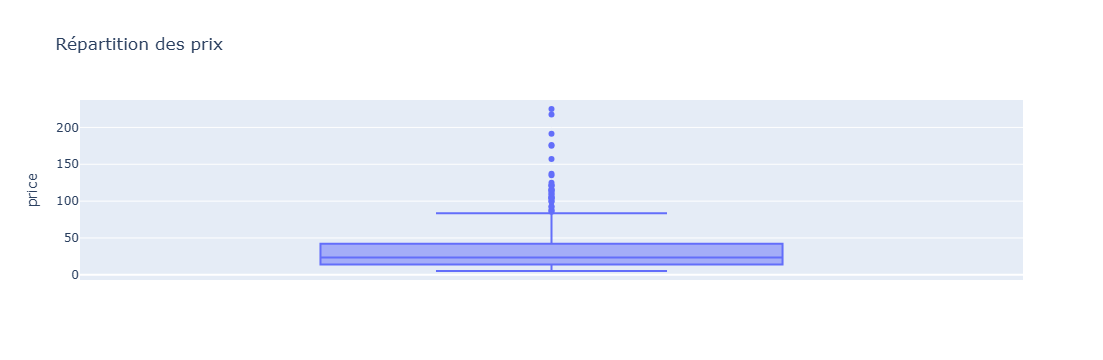

In [74]:
#Autre méthode avec plotly express
fig = px.box(df_merge_web_clean, y='price', title="Répartition des prix")
fig.show()

Actuellement deux fois le même type de graphique : une boîte à moustaches avec pandas, puis la même chose avec plotly. Ça montre la médiane/les quartiles/les valeurs aberrantes, mais pas la forme de la distribution (asymétrie, concentration des prix, etc.). C'est un axe d'amélioration simple et concret.

Prompt A : Dans ce notebook, la distribution des prix est visualisée uniquement avec un boxplot (pandas puis plotly, en double). Propose une visualisation plotly express qui montre à la fois la distribution complète des prix et les valeurs aberrantes.

In [75]:
fig = px.histogram(df_merge_web_clean, x='price', marginal='box', 
                    title="Distribution des prix (avec repérage des outliers)")
fig.show()

Prompt B : Propose une alternative avec la librairie seaborn pour visualiser en un seul graphique la distribution des prix et les valeurs aberrantes.

In [76]:
%matplotlib inline

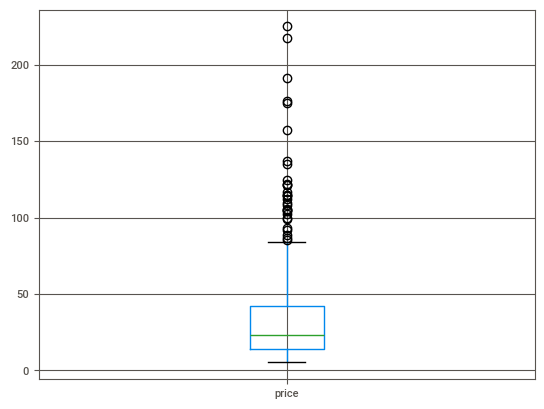

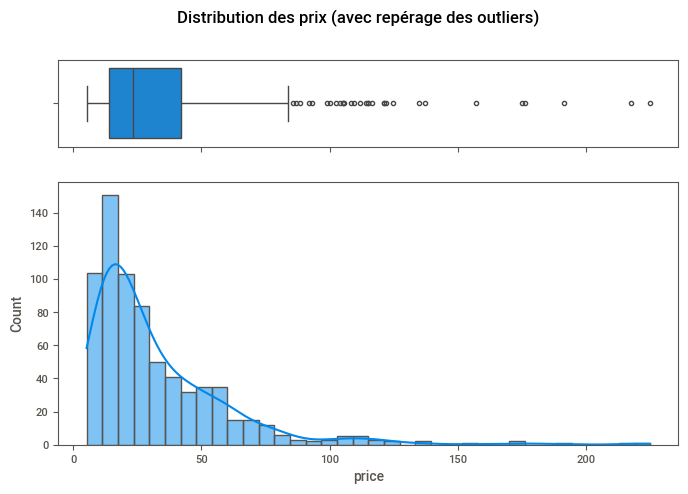

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8,5), sharex=True, gridspec_kw={'height_ratios':[1,3]})
sns.boxplot(x=df_merge_web_clean['price'], ax=axes[0])
sns.histplot(x=df_merge_web_clean['price'], kde=True, ax=axes[1])
axes[0].set(xlabel='')
plt.suptitle("Distribution des prix (avec repérage des outliers)")
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [78]:
#Calculer la moyenne du prix
moyenne_price = df_merge_web_clean['price'].mean()
print("Moyenne du prix : ",moyenne_price)
#Calculer l'écart-type du prix
ecarttype_price = df_merge_web_clean['price'].std()
print("Écart-type du prix : ", ecarttype_price)
#Calculer le Z-score
df_merge_web_clean.loc[:,'price_zscore'] = (df_merge_web_clean['price'] - moyenne_price) / ecarttype_price
display(df_merge_web_clean.head())

Moyenne du prix :  32.33368347338936
Écart-type du prix :  27.5963324191972


C:\Users\kevin\AppData\Local\Temp\ipykernel_20432\2931568676.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,price_zscore
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,-0.294738
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,0.071253
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,-0.417943
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,-0.660729
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,0.495222


In [79]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
outliers = df_merge_web_clean[abs(df_merge_web_clean['price_zscore']) > 3]
display(outliers)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,price_zscore
200,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,6.981591
219,4402,1,176.0,11,instock,78.25,3510,3510,3.0,Cognac,Cognac Frapin VIP XO,5.205993
222,4406,1,157.0,12,instock,69.08,7819,7819,4.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,4.517496
387,4904,1,137.0,9,instock,67.95,14220,14220,3.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,3.792762
434,5001,1,217.5,18,instock,116.87,14581,14581,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014,6.709816
524,5612,1,124.8,19,instock,66.41,14915,14915,1.0,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,3.350674
566,5767,1,175.0,12,instock,90.42,15185,15185,4.0,Vin,Camille Giroud Clos de Vougeot 2016,5.169756
601,5892,1,191.3,98,instock,116.06,14983,14983,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,5.760415
617,5917,1,122.0,12,instock,54.24,14775,14775,3.0,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,3.249211
661,6126,1,135.0,138,instock,80.33,14923,14923,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,3.720288


In [80]:
df_merge_web_clean.groupby('product_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Champagne,28.0,69.626786,47.621631,12.65,39.000,56.00,80.375,225.0
Cognac,8.0,97.500000,48.153208,44.00,61.850,86.05,120.625,176.0
Gin,2.0,36.000000,0.000000,36.00,36.000,36.00,36.000,36.0
Huile d'olive,3.0,24.933333,15.291937,13.10,16.300,19.50,30.850,42.2
Vin,658.0,29.281307,23.456566,5.20,13.500,21.85,38.400,217.5
Whisky,14.0,65.557143,26.060129,27.50,51.375,59.00,61.450,122.0


In [81]:
produits_suspects = df_merge_web_clean[df_merge_web_clean['price_zscore'].abs() > 3]
produits_suspects

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,price_zscore
200,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,6.981591
219,4402,1,176.0,11,instock,78.25,3510,3510,3.0,Cognac,Cognac Frapin VIP XO,5.205993
222,4406,1,157.0,12,instock,69.08,7819,7819,4.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,4.517496
387,4904,1,137.0,9,instock,67.95,14220,14220,3.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,3.792762
434,5001,1,217.5,18,instock,116.87,14581,14581,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014,6.709816
524,5612,1,124.8,19,instock,66.41,14915,14915,1.0,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,3.350674
566,5767,1,175.0,12,instock,90.42,15185,15185,4.0,Vin,Camille Giroud Clos de Vougeot 2016,5.169756
601,5892,1,191.3,98,instock,116.06,14983,14983,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,5.760415
617,5917,1,122.0,12,instock,54.24,14775,14775,3.0,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,3.249211
661,6126,1,135.0,138,instock,80.33,14923,14923,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,3.720288


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [82]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
display(df_merge_web_clean['price'].describe())

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64

In [83]:
# autre méthode ?
Q1 = df_merge_web_clean['price'].quantile(0.25)
Q3 = df_merge_web_clean['price'].quantile(0.75)
IQR = Q3 - Q1

# bornes
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# filtre des outliers
outliers_2 = df_merge_web_clean[(df_merge_web_clean['price'] < lower_bound) |
                               (df_merge_web_clean['price'] > upper_bound)]

display(outliers_2)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,price_zscore
63,4115,1,100.0,12,instock,52.70,15382,15382,1.0,Vin,Zind-Humbrecht Riesling Grand Cru Rangen De Th...,2.452004
200,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,6.981591
219,4402,1,176.0,11,instock,78.25,3510,3510,3.0,Cognac,Cognac Frapin VIP XO,5.205993
220,4404,1,108.5,17,instock,52.22,3507,3507,4.0,Cognac,Cognac Frapin Château de Fontpinot XO,2.760016
222,4406,1,157.0,12,instock,69.08,7819,7819,4.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,4.517496
223,4407,1,104.0,14,instock,46.71,3509,3509,5.0,Cognac,Cognac Frapin Cigar Blend,2.596951
229,4582,1,109.6,18,instock,53.80,12857,12857,1.0,Vin,Château de Meursault Puligny-Montrachet 1er Cr...,2.799876
386,4903,1,102.3,12,instock,51.80,14805,14805,2.0,Vin,Domaine Des Croix Corton Grand Cru Les Grèves ...,2.535348
387,4904,1,137.0,9,instock,67.95,14220,14220,3.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,3.792762
434,5001,1,217.5,18,instock,116.87,14581,14581,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014,6.709816


In [84]:
#Définir un seuil pour les articles "outliers" en prix
# display(outliers)

In [85]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
nb_outliers = outliers_2.shape[0]
proportion_outliers = nb_outliers / df_merge_web_clean.shape[0]*100
print("Nombre d'articles en outliers : ", nb_outliers)
print("Proportion de l'ensemble du catalogue : ", proportion_outliers)

Nombre d'articles en outliers :  26
Proportion de l'ensemble du catalogue :  3.6414565826330536


In [86]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
print("il faut comparer avec les prix sur internet ?")

il faut comparer avec les prix sur internet ?


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [87]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge_web_clean['ca_par_article'] = df_merge_web_clean['price'] * df_merge_web_clean['total_sales']
#Calculer la somme de la colonne "ca_par_article"
total_ca = df_merge_web_clean['ca_par_article'].sum()
#Ce résultat correspond au chiffre d'affaire du site web
print("Le CA du site web est de : ", total_ca)

Le CA du site web est de :  143680.09999999998


C:\Users\kevin\AppData\Local\Temp\ipykernel_20432\4219476625.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



    product_id  onsale_web  price  stock_quantity stock_status  \
0         4352           1  225.0               0   outofstock   
1         5892           1  191.3              98      instock   
2         4353           1   79.5             127      instock   
3         5826           1   41.2              34      instock   
4         6212           1  115.0              16      instock   
5         5026           1   86.8             101      instock   
6         5008           1  105.0              12      instock   
7         5767           1  175.0              12      instock   
8         6126           1  135.0             138      instock   
9         5025           1  112.0             136      instock   
10        6201           1  105.6              16      instock   
11        4406           1  157.0              12      instock   
12        4647           1   28.5              45      instock   
13        4358           1   77.0              81      instock   
14        

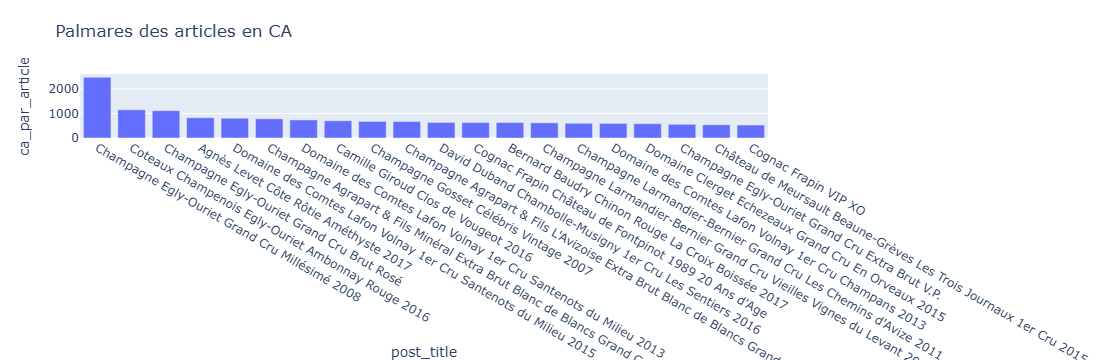

In [88]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge_web_clean = df_merge_web_clean.sort_values(by='ca_par_article', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_merge_web_clean = df_merge_web_clean.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
print(df_merge_web_clean.head(20))
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_merge_web_clean.head(20), x='post_title', y='ca_par_article', title='Palmares des articles en CA')
fig.show()

In [89]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge_web_clean['part_ca'] = df_merge_web_clean['ca_par_article'] / total_ca
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_web_clean['part_ca_cumul'] = df_merge_web_clean['part_ca'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
somme_80 = df_merge_web_clean[df_merge_web_clean['part_ca_cumul'] <= 0.8].shape[0]
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80 = somme_80 / df_merge_web_clean.shape[0]*100
print("Proportion des articles représentant 80% du CA : ", proportion_80)

Proportion des articles représentant 80% du CA :  60.78431372549019


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,price_zscore,ca_par_article,part_ca,part_ca_cumul
0,4867,1,9.9,121,instock,4.86,16148,16148,36.0,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,-0.812923,356.4,0.002481,0.227993
1,4203,1,9.9,74,instock,5.01,15415,15415,27.0,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,-0.812923,267.3,0.001860,0.402390
2,4275,1,14.9,62,instock,7.78,14864,14864,24.0,Vin,I Fabbri Chianti Classico Lamole 2017,-0.631739,357.6,0.002489,0.215575
3,4726,1,12.7,0,outofstock,6.82,14950,14950,22.0,Vin,François Baur Pinot Noir Schlittweg 2017,-0.711460,279.4,0.001945,0.368073
4,4647,1,28.5,45,instock,14.14,16525,16525,22.0,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,-0.138920,627.0,0.004364,0.082242
5,5826,1,41.2,34,instock,21.71,15325,15325,20.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,0.321286,824.0,0.005735,0.038696
6,6129,1,5.2,68,instock,2.74,14570,14570,20.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,-0.983235,104.0,0.000724,0.951251
7,4220,1,11.6,48,instock,5.75,15758,15758,18.0,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,-0.751320,208.8,0.001453,0.579007
8,5803,1,17.1,47,instock,9.19,13572,13572,17.0,Vin,Château Tour Haut-Caussan Médoc 2015,-0.552018,290.7,0.002023,0.340271
9,6569,1,29.0,58,instock,15.28,15705,15705,17.0,Vin,Decelle-Villa Chorey-Lès-Beaune 2016,-0.120802,493.0,0.003431,0.124229


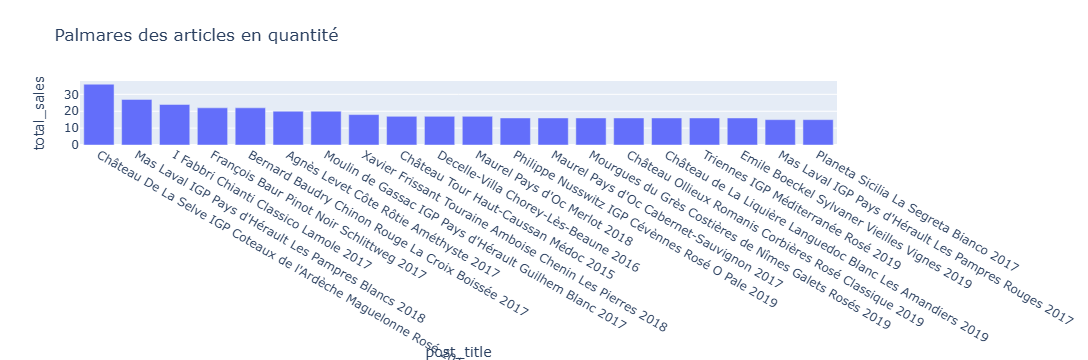

In [90]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge_web_clean = df_merge_web_clean.sort_values(by='total_sales', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_merge_web_clean = df_merge_web_clean.reset_index(drop=True)
#Afficher les 20 premiers articles en quantité
display(df_merge_web_clean.head(20))
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_merge_web_clean.head(20), x='post_title', y='total_sales', title='Palmares des articles en quantité')
fig.show()

In [91]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge_web_clean['part_quantite'] = df_merge_web_clean['total_sales'] / df_merge_web_clean['total_sales'].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_web_clean['part_quantite_cumul'] = df_merge_web_clean['part_quantite'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qte = df_merge_web_clean[df_merge_web_clean['part_quantite_cumul'] <= 0.8].shape[0]
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80_qte = nb_articles_80_qte / df_merge_web_clean.shape[0]*100
print("Proportion des articles représentant 80% des ventes en quantité : ", proportion_80_qte)

Proportion des articles représentant 80% des ventes en quantité :  60.64425770308123


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [92]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy (deja fait)

#Création de la colonne Rotation de stock
#Remplacement des "inf" par 0
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
#df_merge_web_clean = df_merge_web_clean.sort_values(by='stock_quantity', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
#df_merge_web_clean = df_merge_web_clean.reset_index(drop=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
#fig = px.bar(df_merge_web_clean.head(20), x='post_title', y='stock_quantity', title='Flop 20 des produits qui ont le plus de mois de stock')
#fig.show()

In [93]:
df_merge_web_clean['mois_stock'] = df_merge_web_clean['stock_quantity'] / df_merge_web_clean['total_sales']
df_merge_web_clean['mois_stock'].replace([np.inf, -np.inf], 0, inplace=True)
df_merge_web_clean['mois_stock'].fillna(0, inplace=True)
df_merge_web_clean = df_merge_web_clean.sort_values(by='mois_stock', ascending=False).reset_index(drop=True)

fig = px.bar(df_merge_web_clean.head(20), x='post_title', y='mois_stock', title='Flop 20 des produits selon les mois de stock')
fig.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_20432\798726083.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\kevin\AppData\Local\Temp\ipykernel_20432\798726083.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [94]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge_web_clean['valorisation_stock_euros'] = df_merge_web_clean['stock_quantity'] * df_merge_web_clean['purchase_price']
#Calculer la somme de la colonne "Valorisation_stock_euros"
somme_stock_euros = df_merge_web_clean['valorisation_stock_euros'].sum()
somme_stock_euros

np.float64(277305.77)

In [95]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
somme_stock_quantity = df_merge_web_clean['stock_quantity'].sum()
somme_stock_quantity

np.int64(16739)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [96]:
df_merge_web_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                714 non-null    int64  
 1   onsale_web                714 non-null    int64  
 2   price                     714 non-null    float64
 3   stock_quantity            714 non-null    int64  
 4   stock_status              714 non-null    object 
 5   purchase_price            714 non-null    float64
 6   id_web                    714 non-null    object 
 7   sku                       714 non-null    object 
 8   total_sales               714 non-null    float64
 9   product_type              713 non-null    object 
 10  post_title                714 non-null    object 
 11  price_zscore              714 non-null    float64
 12  ca_par_article            714 non-null    float64
 13  part_ca                   714 non-null    float64
 14  part_ca_cu

In [97]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge_web_clean = df_merge_web_clean.sort_values(by='price', ascending=False)
df_merge_web_clean['prix_ht'] = df_merge_web_clean['price'] / 1.2
#Création de la colonne Taux de marge
df_merge_web_clean['taux_marge'] = (df_merge_web_clean['prix_ht'] - df_merge_web_clean['purchase_price']) / df_merge_web_clean['prix_ht'] *100
#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum de la colonne taux_marge (%): ", df_merge_web_clean['taux_marge'].min())
#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum de la colonne taux_marge (%): ", df_merge_web_clean['taux_marge'].max())

Taux de marge minimum de la colonne taux_marge (%):  -634.98814229249
Taux de marge maximum de la colonne taux_marge (%):  47.7568


In [98]:
#Affichage de la ligne avec un taux de marge inférieur à 0
display(df_merge_web_clean[df_merge_web_clean['taux_marge'] < 0])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,...,price_zscore,ca_par_article,part_ca,part_ca_cumul,part_quantite,part_quantite_cumul,mois_stock,valorisation_stock_euros,prix_ht,taux_marge
668,4355,1,12.65,97,instock,77.48,12589,12589,0.0,Champagne,...,-0.713272,0.0,0.0,1.0,0.0,1.0,0.0,7515.56,10.541667,-634.988142


In [99]:
#Création d'un dataframe avec les taux positifs
df_taux_marge_pos = df_merge_web_clean[df_merge_web_clean['taux_marge'] > 0]
#Afficher le prix minimum de la colonne "taux_marge"
print("Prix minimum de la colonne taux_marge : ", df_taux_marge_pos['taux_marge'].min())
#Afficher le prix maximum de la colonne "taux_marge"
print("Prix maximum de la colonne taux_marge : ", df_taux_marge_pos['taux_marge'].max())

Prix minimum de la colonne taux_marge :  22.77862595419847
Prix maximum de la colonne taux_marge :  47.7568


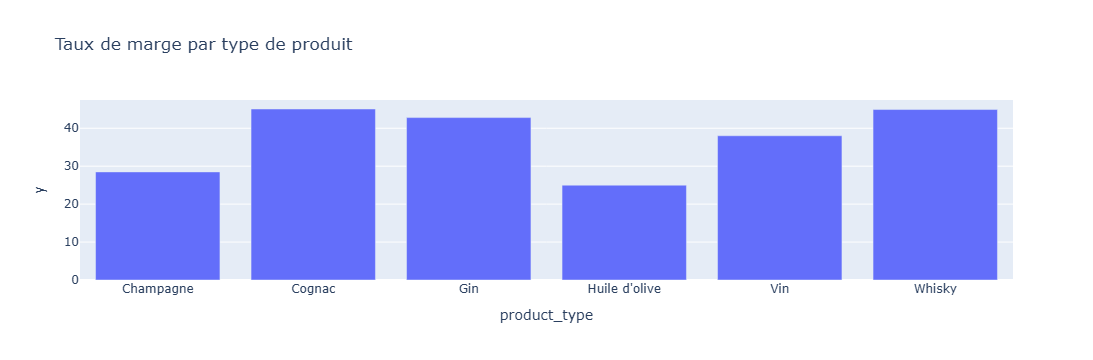

In [100]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge_moyen = df_taux_marge_pos.groupby('product_type')['taux_marge'].mean()
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(df_taux_marge_moyen, x=df_taux_marge_moyen.index, y=df_taux_marge_moyen.values, title='Taux de marge par type de produit')
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

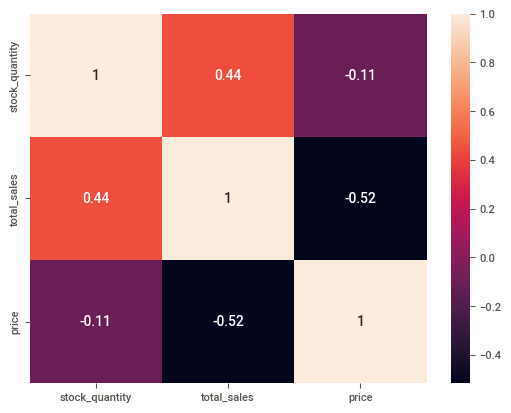

In [101]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
#Création d'une heatmap de corrélation avec les variables stock, sales et price
sns.heatmap(df_merge_web_clean[['stock_quantity', 'total_sales', 'price']].corr(), annot=True)
#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(df_merge_web_clean[['stock_quantity', 'total_sales', 'price']].corr()))

In [102]:
#Que peut-on conclure des corrélations ?
print("quand le stock augmente, les prix baissent et les ventes augmentent")


quand le stock augmente, les prix baissent et les ventes augmentent


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [103]:
# Export du DataFrame vers un fichier Excel
df_merge_web_clean.to_excel("df_merge_web_clean.xlsx", index=False)

# Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
